In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

**Ejercicio 2.** La ecuación logística es un modelo simple para el crecimiento de una población $P$, dada su tasa de crecimiento $r$ y la capacidad de carga del ambiente $K$. Puede expresarse del siguiente modo:

$$
\dot{P} = rP\left(1 - \frac{P}{K}\right)
$$

**(a)** Resolver la ecuación para distintos datos iniciales e interpretar el resultado obtenido.

(c) La solución exacta de la ecuación viene dada por:

$$
P(t)=\frac{K}{1+\left(\frac{K-P_0}{P_0}\right)e^{-rt}}
$$

Elegir algún valor de $P_0$ y graficarla junto con las soluciones aproximadas para distintos valores de $h$.

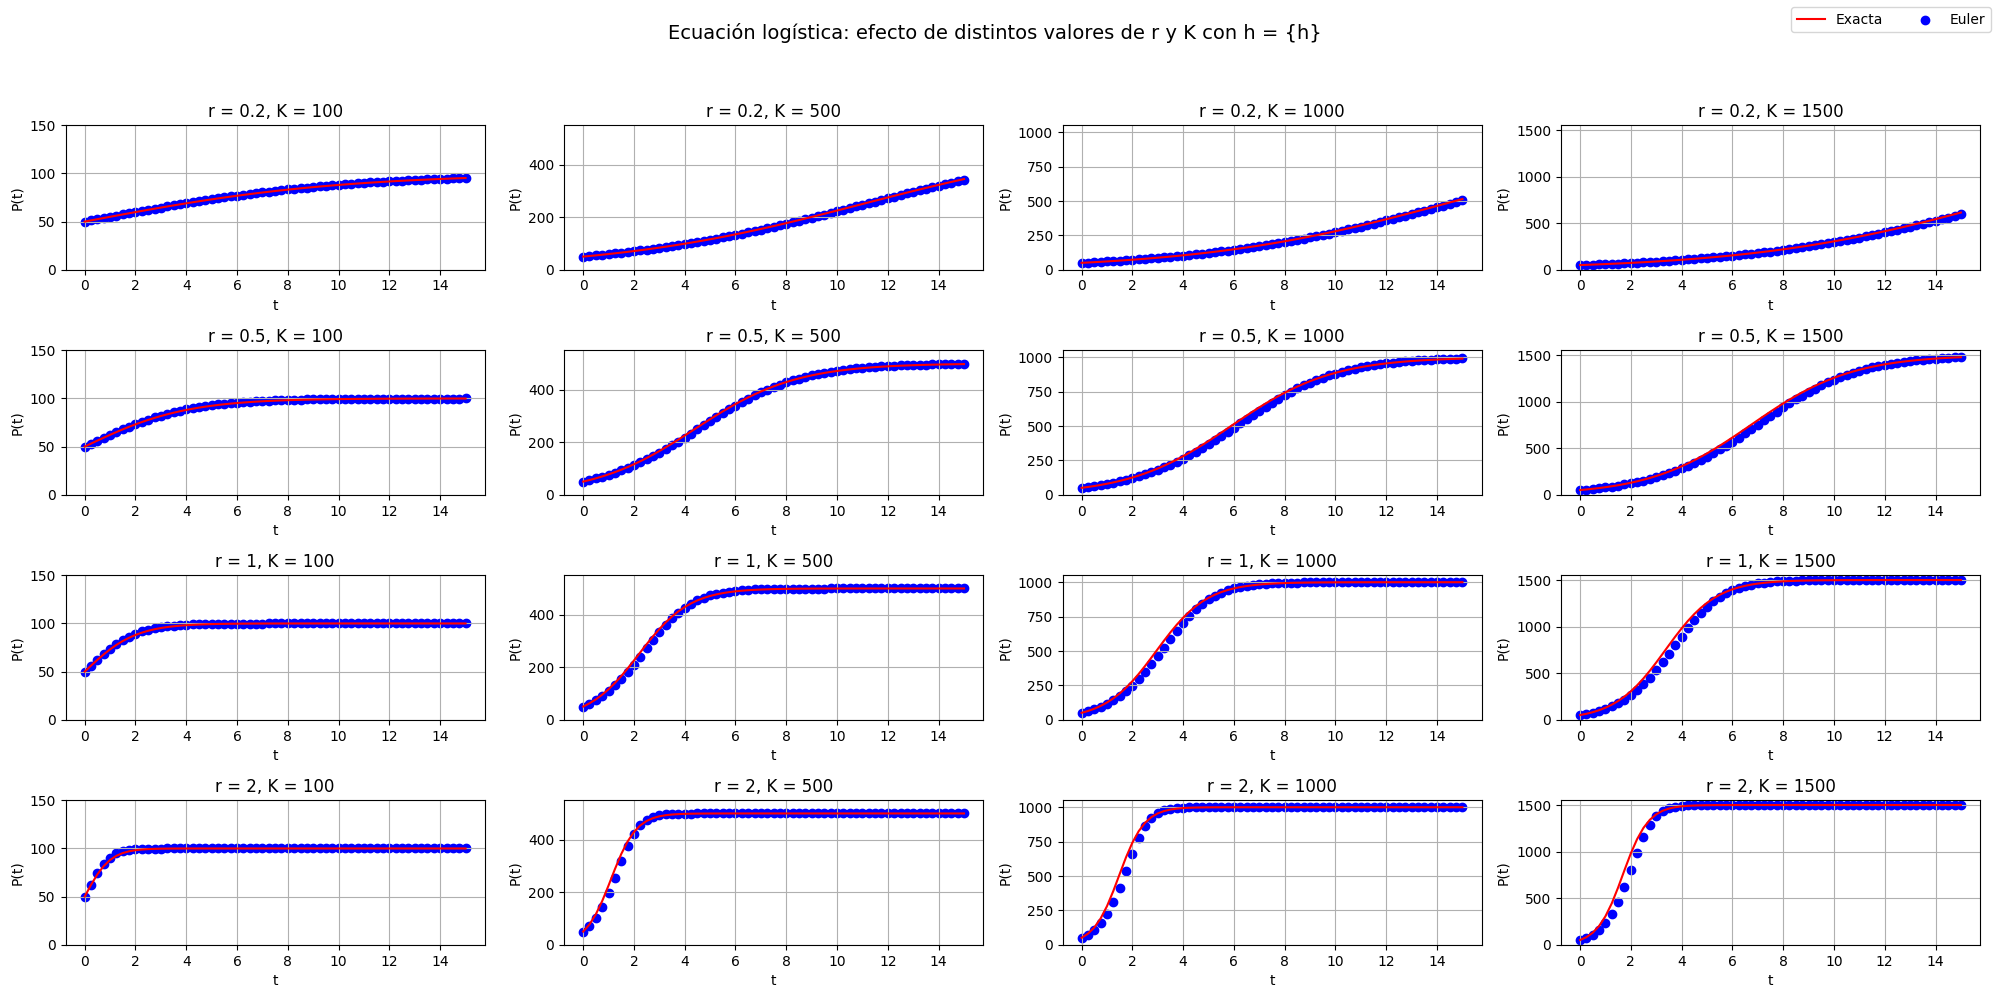

In [3]:
def euler_logistica(r, K, P0, t0, tf, h):
    def f(t, P):
        return r * P * (1 - P/K)

    t_valores = [t0]
    P_valores = [P0]

    t_actual = t0
    P_actual = P0

    while t_actual < tf:
        P_actual = P_actual + f(t_actual, P_actual) * h
        t_actual = t_actual + h

        t_valores.append(t_actual)
        P_valores.append(P_actual)

    return np.array(t_valores), np.array(P_valores)

def solucion_exacta(r, K, P0, t):
    return K / (1 + ((K - P0) / P0) * np.exp(-r * t))


# Parámetros

r_vals = [0.2, 0.5, 1, 2]
K_vals = [100, 500, 1000, 1500]

P0 = 50
t0 = 0
tf = 15
h = 0.25

# Gráfico

fig, axes = plt.subplots(len(r_vals), len(K_vals), figsize=(20, 10))

for i, r in enumerate(r_vals):
    for j, K in enumerate(K_vals):
        ax = axes[i, j]
        
        # Euler
        t_euler, P_euler = euler_logistica(r, K, P0, t0, tf, h)

        ax.plot(t_euler, solucion_exacta(r, K, P0, t_euler), label='Exacta', color='red')
        ax.scatter(t_euler, P_euler, label='Euler', color='blue')
        ax.set_title(f'r = {r}, K = {K}')
        ax.grid(True)
        ax.set_ylim(0, K+50)

        ax.set_xlabel('t')
        ax.set_ylabel('P(t)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=2)

fig.suptitle('Ecuación logística: efecto de distintos valores de r y K con h = {h}', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
